In [1]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

In [2]:
const devisions = 64

function operate(time, Δf)
    iter = time * devisions * Δf
    t_range = range(1, iter)
    conv = []
    for i in t_range
        push!(conv, (i * 1/Δf)/devisions)
    end
    return conv
end

function operate_2(time, Δf)
    iter = time * devisions
    t_range = range(1, iter)
    conv = []
    for i in t_range
        push!(conv, (i * 1/Δf)/devisions)
    end
    return conv
end

operate_2 (generic function with 1 method)

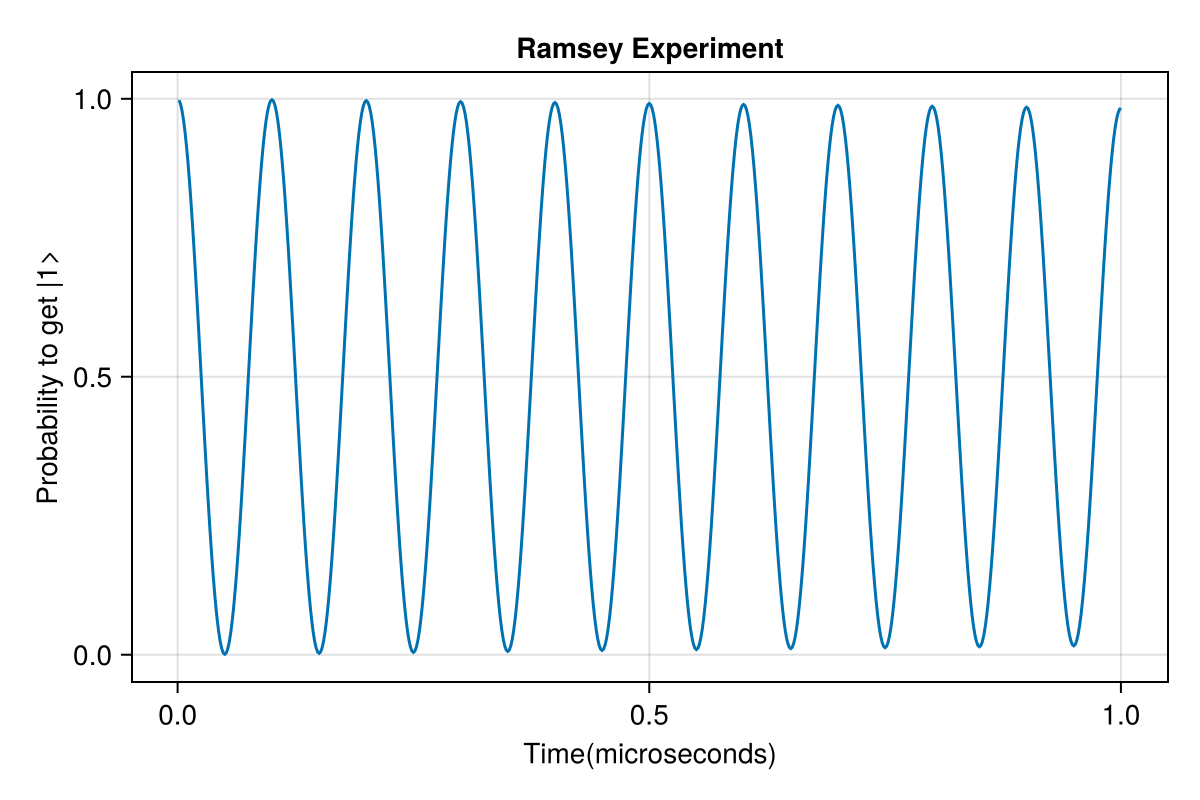

CairoMakie.Screen{IMAGE}


In [3]:
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000
function Probability_Ramsey(Δ, time)
    Ts = operate(time, Δ)   
    function P(t)
        return 0.5 * exp(-t/T2x) * cos(2π * Δ * t) + 0.5
    end
    decaying = []
    for i in Ts
        push!(decaying, P(i))
    end

    return Ts, decaying
end

Δf = 10#MHz
t = 1
Decay = Probability_Ramsey(Δf, t)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Decay[1], Decay[2] )
display(fig)

In [4]:
Δ_start = 1
Δ_final = 5
t_start = 1
t_final = 30

delta_range = range(Δ_start,Δ_final; step = 1)
t_range = range(t_start,t_final; step = 1)
A = Vector{Any}(zeros(length(delta_range)))
for Δ in delta_range
    t_lst = []
    for t in t_range
        push!(t_lst, Probability_Ramsey(Δ, t)[2])
    end
    A[Δ] = t_lst
end

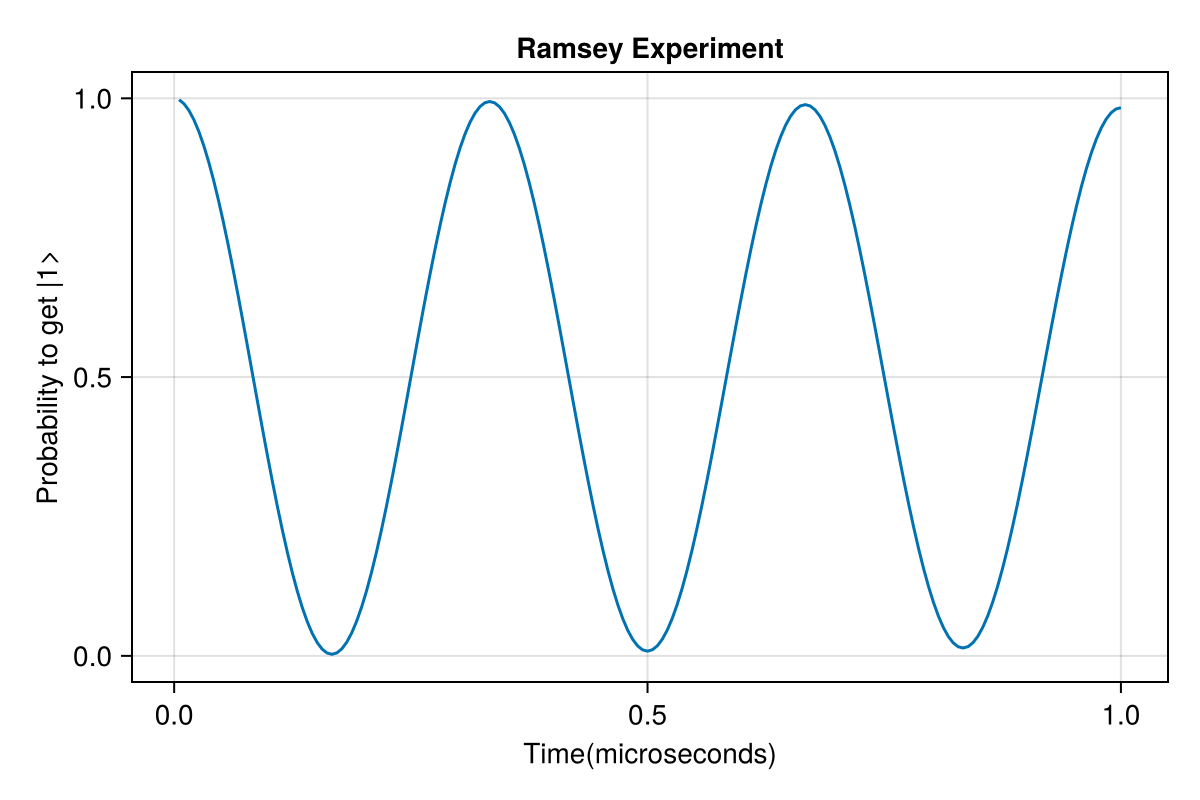

CairoMakie.Screen{IMAGE}


In [16]:
delta_index = 2
time_index = 1
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, operate(time_index, delta_index + 1), A[delta_index + 1][time_index])
#lines!(ax, operate(time_index +1, delta_index), A[delta_index][time_index + 1])

display(fig)

#the time index says until what second I go till
#the delta index says what delta is so there are delta_index+1 peaks in the time interval because precession time is 1/delta_index

In [8]:
# function Probability_Ramsey_2(Δ, time)
#     Ts = operate_2(time, Δ)   
#     function P(t)
#         return 0.5 * exp(-t/T2x) * cos(2π * Δ * t) + 0.5
#     end
#     decaying = []
#     for i in Ts
#         push!(decaying, P(i))
#     end

#     return Ts, decaying
# end


# max_time = 30
# ys = range(1,5) #delta values
# xs, _ = Probability_Ramsey_2(ys[1], max_time) #time range with Δ = 1 and t=max_time=10 making a Ts of length 640
# zs = zeros(length(ys), length(xs)) #2D array
# zs

# for (i,Δ) in enumerate(ys)
#     _, decay = Probability_Ramsey_2(Δ,max_time)
#     zs[i, :] = decay 
# end

# fig, ax, hm = heatmap(xs, ys, zs, colormap = :viridis)
# Colorbar(fig[:, end+1], hm)
# fig

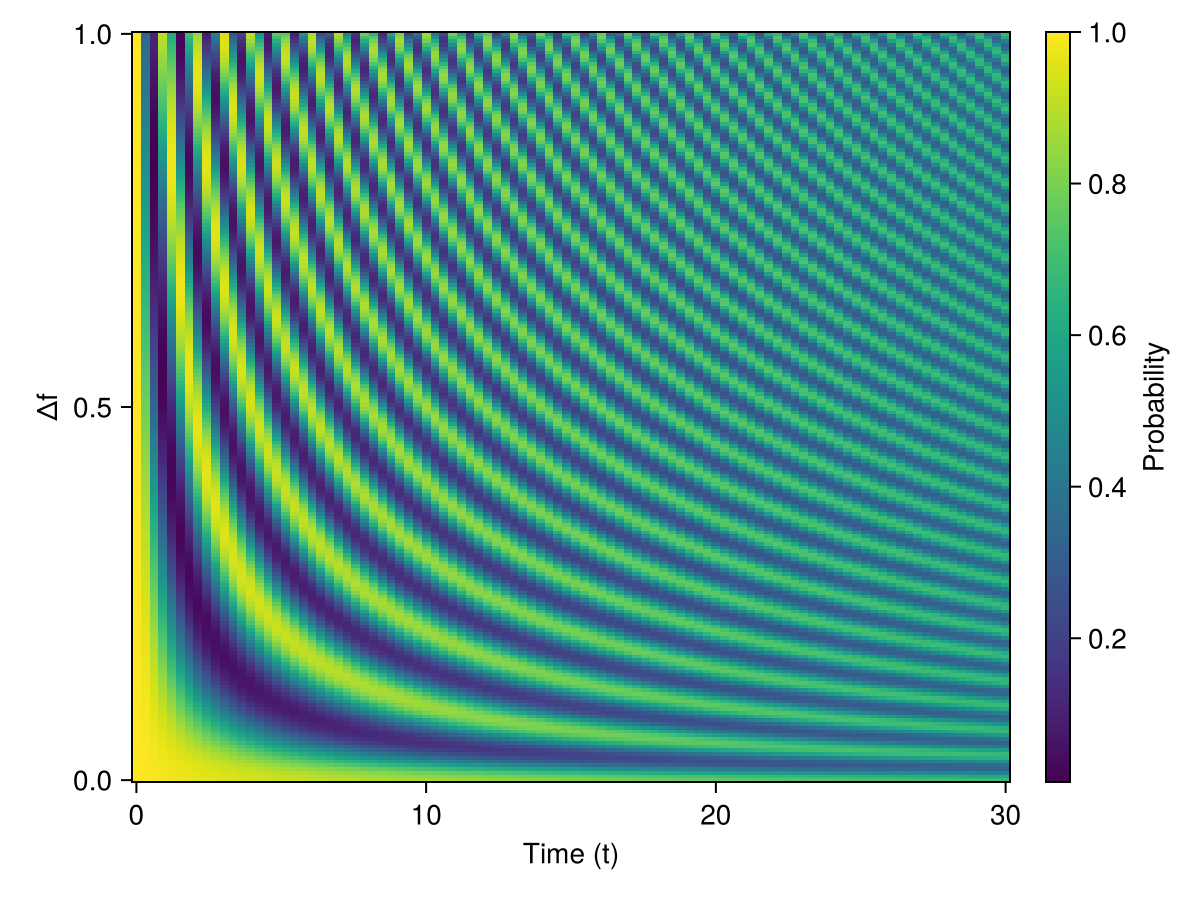

In [10]:
xs = range(0, 30.0, length=100)  # time
ys = range(0, 1.0, length=200) #Δf
zs = zeros(length(xs), length(ys)) #2D array
function P(t,Δ)
    return 0.5 * exp(-t/T2x) * cos(2π * Δ * t) + 0.5
end

for (i, Δf) in enumerate(ys)
    over_times = []
    for t in xs
        push!(over_times, P(t,Δf))
    end
    zs[:,i] = over_times
end

 fig, ax, hm = heatmap(xs, ys, zs, colormap = :viridis)
ax.ylabel = "Δf"
ax.xlabel = "Time (t)"
Colorbar(fig[:, end+1], hm, label = "Probability")
fig


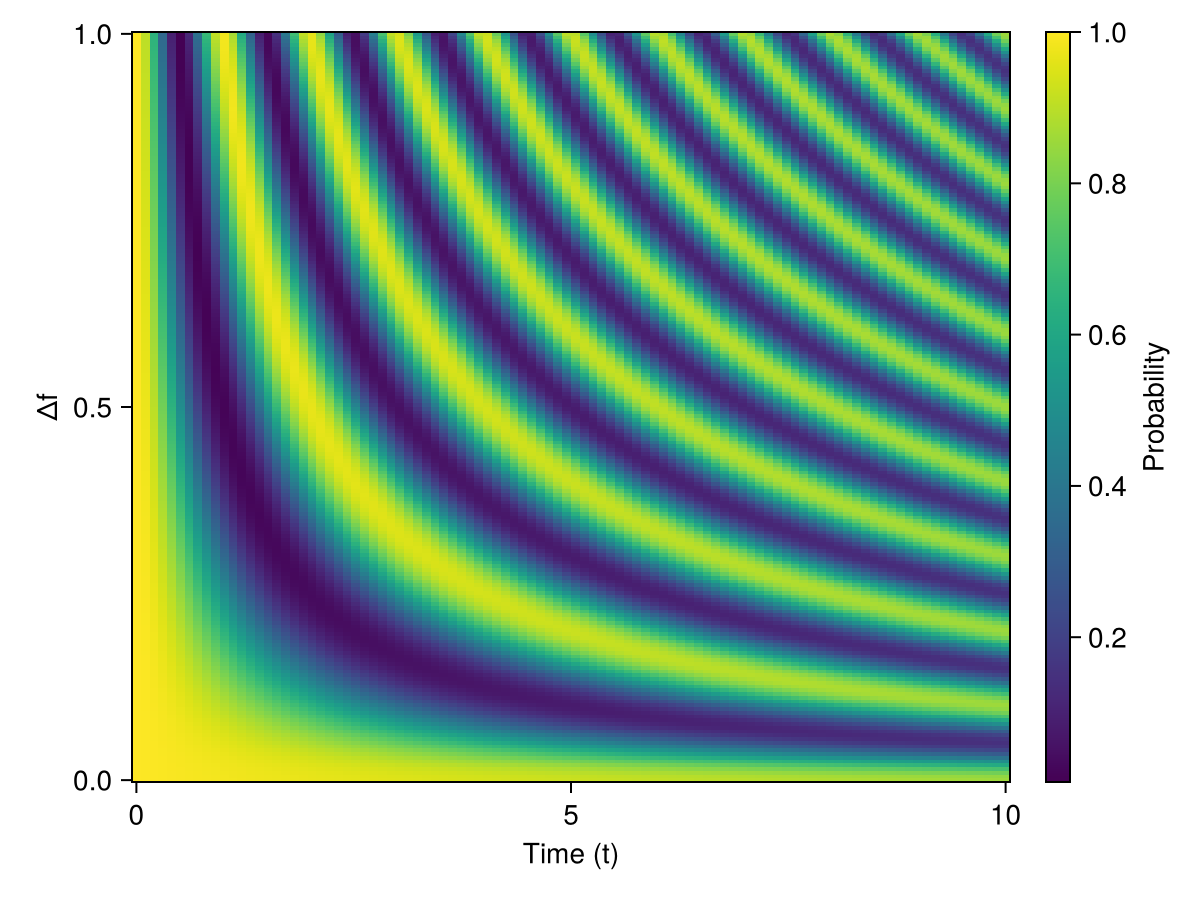

In [15]:

xs = range(0, 10.0, length=100)  # time
#Δf = 1
#ys = range(Δf, Δf) #Δf
ys = range(0, 1.0, length=200) #Δf
zs = zeros(length(xs), length(ys)) #2D array
function P(t,Δ)
    return 0.5 * exp(-t/T2x) * cos(2π * Δ * t) + 0.5
end

for (i, Δf) in enumerate(ys)
    over_times = []
    for t in xs
        push!(over_times, P(t,Δf))
    end
    zs[:,i] = over_times
end

 fig, ax, hm = heatmap(xs, ys, zs, colormap = :viridis)
ax.ylabel = "Δf"
ax.xlabel = "Time (t)"
Colorbar(fig[:, end+1], hm, label = "Probability")
fig

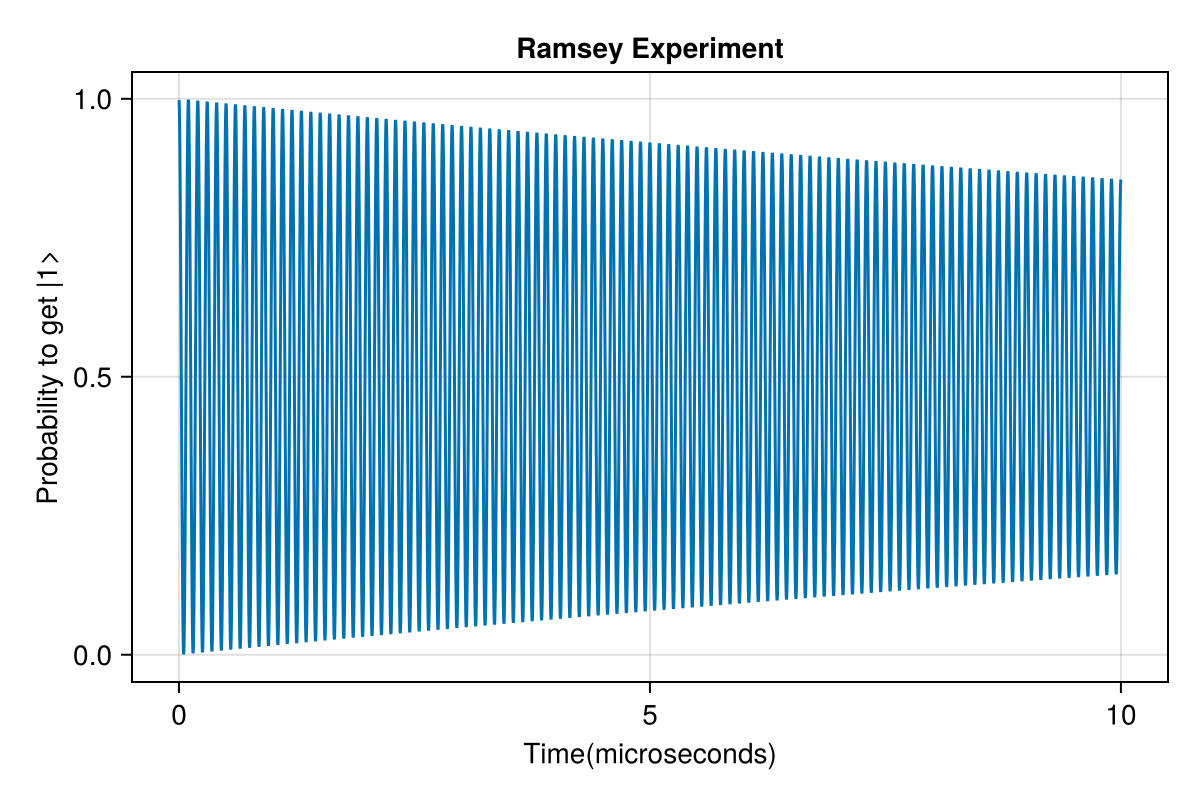

CairoMakie.Screen{IMAGE}


In [13]:
t = 10
Decay = Probability_Ramsey(Δf, t)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Decay[1], Decay[2] )
display(fig)
